### function

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [90]:
def visualize_parallel_coordinates(
    df: pd.DataFrame, 
    title: str,
    metrics: list,
    metric_names: list,
    metric_directions: list, 
    label_col: str = 'Label',
    color_group_col: str = 'Scheduler'
):
    """
    Generic parallel coordinates plot for model metric evaluation.
    
    :param metrics: List of column names in df to use as axes.
    :param metric_names: Human-readable titles for the axes.
    :param metric_directions: List of 'lower' or 'higher' denoting which direction is "better" for normalization.
    """
    
    # 1. Automated Normalization
    norm_cols = []
    for metric, direction in zip(metrics, metric_directions):
        min_val = df[metric].min()
        max_val = df[metric].max()
        norm_col = f"Norm_{metric}"
        norm_cols.append(norm_col)
        
        # Handle normalization based on whether lower or higher is better
        if max_val == min_val:
            df[norm_col] = 0.5  # Neutral middle if all values are identical
        elif direction == 'lower':
            df[norm_col] = (max_val - df[metric]) / (max_val - min_val)
        else: # 'higher'
            df[norm_col] = (df[metric] - min_val) / (max_val - min_val)

    # 2. Setup Plot
    fig, ax = plt.subplots(figsize=(12, 7))

    # Dynamic color mapping (maintains previous color scheme, adds defaults for new schedulers)
    unique_groups = df[color_group_col].unique()
    base_colors = {"Warmup-Stable-Only (WSO)": "#E32636", "WSO": "#E32636", "WSD": "#2ca02c", "Linear": "#1f77b4", "Cosine": "#9467bd"}
    default_colors = plt.cm.tab10.colors
    
    group_colors = {grp: base_colors.get(grp, default_colors[i % len(default_colors)]) for i, grp in enumerate(unique_groups)}
    
    # Track styles dynamically per group so variants look distinct
    group_style_tracker = {grp: 0 for grp in unique_groups}
    styles = ['-', '--', ':', '-.']

    legend_elements = []

    # 3. Draw Lines
    for idx, row in df.iterrows():
        grp = row[color_group_col]
        label = row[label_col]
        color = group_colors[grp]
        
        # Emphasize WSO, cycle styles for the rest
        if 'WSO' in grp:
            style = '-'
            lw = 4
            alpha_val = 1.0
        else:
            style = styles[group_style_tracker[grp] % len(styles)]
            group_style_tracker[grp] += 1
            lw = 2
            alpha_val = 0.7
            
        x_coords = list(range(len(metrics)))
        y_coords = [row[c] for c in norm_cols]
        
        ax.plot(x_coords, y_coords, color=color, linestyle=style, linewidth=lw, alpha=alpha_val, marker='o', markersize=8)
        legend_elements.append(Line2D([0], [0], color=color, lw=lw, linestyle=style, label=label))

    ax.set_xlim(-0.3, len(metrics) - 0.7)
    ax.set_ylim(-0.05, 1.05)

    # 4. Axes Formatting (Supports N-number of metrics)
    for x in range(len(metrics)):
        ax.axvline(x=x, color='black', linewidth=2, zorder=1)
        dir_text = "Lower is Better" if metric_directions[x] == 'lower' else "Higher is Better"
        ax.text(x, 1.08, f"{metric_names[x]}\n({dir_text})", ha='center', va='bottom', fontsize=12)

    ax.axis('off') # Hides default matplotlib box/spines cleanly

    # 5. Add Text Labels for the Points
    for x_pos, (raw_col, norm_col) in enumerate(zip(metrics, norm_cols)):
        unique_points = df[[raw_col, norm_col]].drop_duplicates()
        
        # Keep labels on the left side of the first axis, right side of the rest
        ha = 'right' if x_pos == 0 else 'left'
        offset = -0.04 if x_pos == 0 else 0.04
        
        for _, row in unique_points.iterrows():
            raw_val = row[raw_col]
            y_pos = row[norm_col]
            
            # Format strings: Loss usually has 3 decimals, tasks usually 1
            if 'Loss' in raw_col:
                val_str = f"+{raw_val:.3f}" if raw_val > 0 else f"{raw_val:.3f}"
            else:
                val_str = f"+{raw_val:.1f}" if raw_val > 0 else f"{raw_val:.1f}"
                
            ax.text(x_pos + offset, y_pos, val_str, ha=ha, va='center', fontsize=11, zorder=10, 
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=0.5))

    # 6. Finalize Legend & Title
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1), title="Model Setup", borderaxespad=0.)

    plt.title(title, fontsize=16, fontweight='bold', pad=50)
    plt.tight_layout()
    plt.show()

### plots

#### 1B PT + SFT

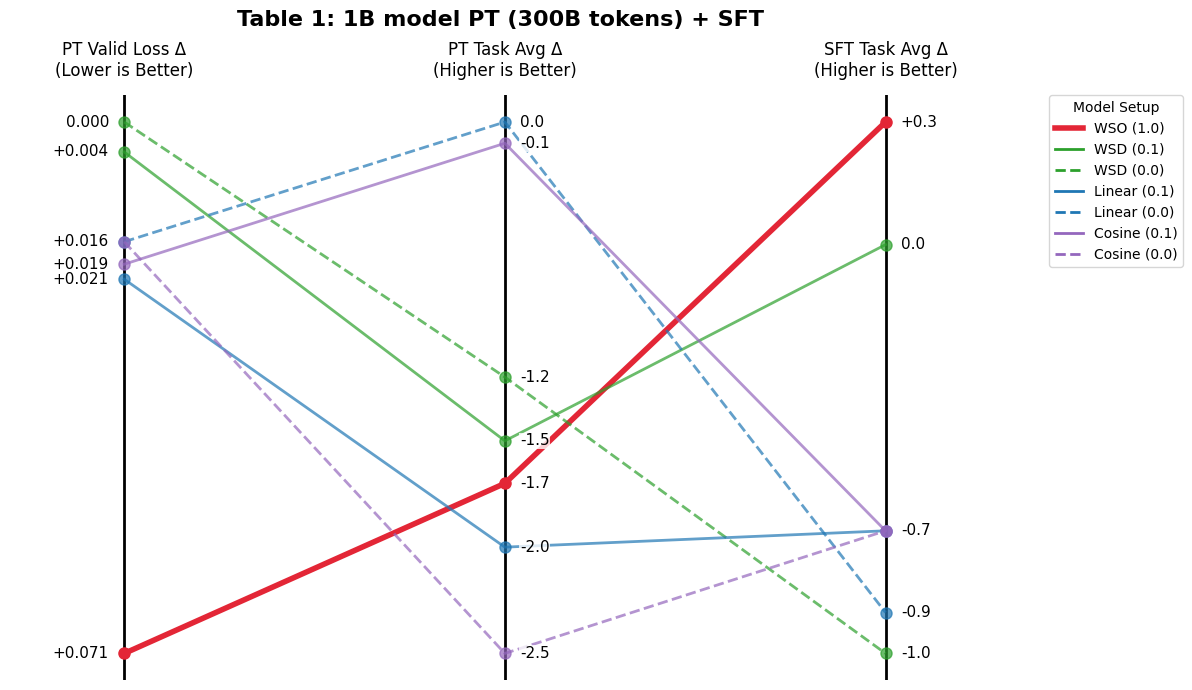

In [91]:
# 1. Raw Data Extraction directly from Table 1 (1B Model)
title = "Table 1: 1B model PT (300B tokens) + SFT "
data_t1_1b = [
    {"Scheduler": "Warmup-Stable-Only (WSO)", "Alpha_pre": "1.0", "PT_Valid_Loss_Delta": 0.071, "PT_Task_Avg_Delta": -1.7, "SFT_Task_Avg_Delta": 0.3, "Label": "WSO (1.0)"},
    {"Scheduler": "WSD", "Alpha_pre": "0.1", "PT_Valid_Loss_Delta": 0.004, "PT_Task_Avg_Delta": -1.5, "SFT_Task_Avg_Delta": 0.0, "Label": "WSD (0.1)"},
    {"Scheduler": "WSD", "Alpha_pre": "0.0", "PT_Valid_Loss_Delta": 0.000, "PT_Task_Avg_Delta": -1.2, "SFT_Task_Avg_Delta": -1.0, "Label": "WSD (0.0)"},
    {"Scheduler": "Linear", "Alpha_pre": "0.1", "PT_Valid_Loss_Delta": 0.021, "PT_Task_Avg_Delta": -2.0, "SFT_Task_Avg_Delta": -0.7, "Label": "Linear (0.1)"},
    {"Scheduler": "Linear", "Alpha_pre": "0.0", "PT_Valid_Loss_Delta": 0.016, "PT_Task_Avg_Delta": 0.0, "SFT_Task_Avg_Delta": -0.9, "Label": "Linear (0.0)"},
    {"Scheduler": "Cosine", "Alpha_pre": "0.1", "PT_Valid_Loss_Delta": 0.019, "PT_Task_Avg_Delta": -0.1, "SFT_Task_Avg_Delta": -0.7, "Label": "Cosine (0.1)"},
    {"Scheduler": "Cosine", "Alpha_pre": "0.0", "PT_Valid_Loss_Delta": 0.016, "PT_Task_Avg_Delta": -2.5, "SFT_Task_Avg_Delta": -0.7, "Label": "Cosine (0.0)"},
]
df_1b = pd.DataFrame(data_t1_1b)

metrics_to_plot = ["PT_Valid_Loss_Delta", "PT_Task_Avg_Delta", "SFT_Task_Avg_Delta"]
metric_display_names = ["PT Valid Loss Δ", "PT Task Avg Δ", "SFT Task Avg Δ"]
directions = ["lower", "higher", "higher"]

# Using your updated function name
visualize_parallel_coordinates(
    df=df_1b, 
    title=title,
    metrics=metrics_to_plot,
    metric_names=metric_display_names,
    metric_directions=directions,
    label_col="Label" 
)

#### 1B PT + MT + SFT

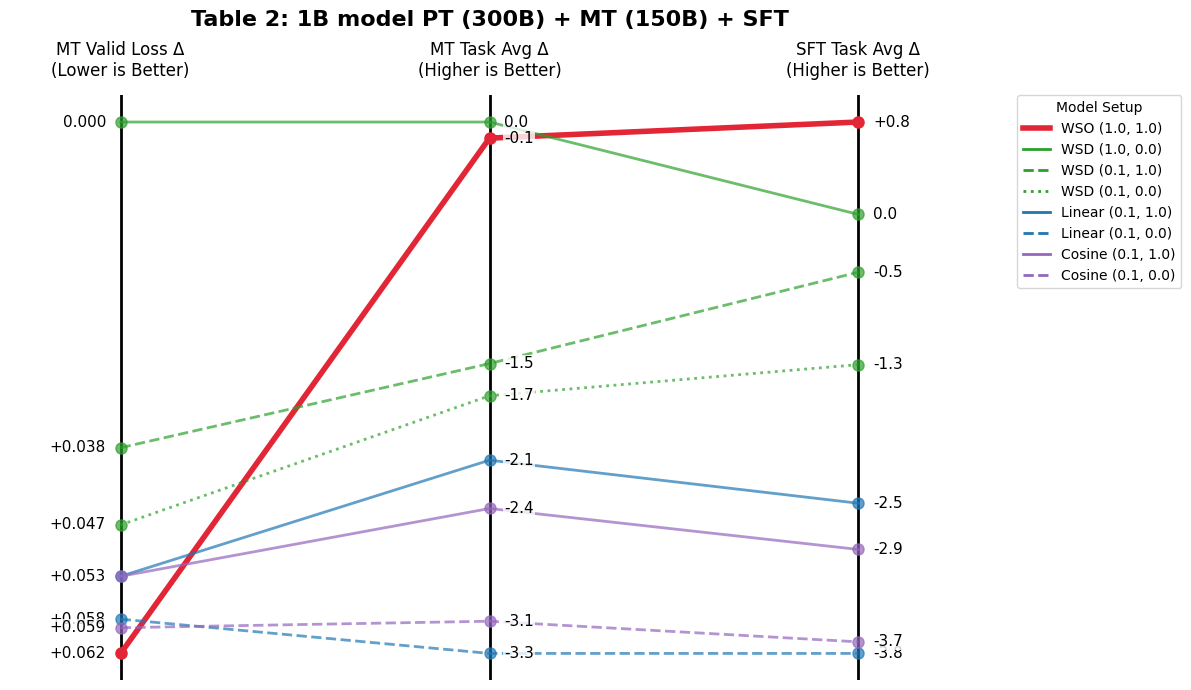

In [92]:
# 1. Raw Data Extraction directly from Table 2 (1B Model)
title = "Table 2: 1B model PT (300B) + MT (150B) + SFT"
data_t2_1b = [
    {"Scheduler": "Warmup-Stable-Only (WSO)", "Alpha_pre": "1.0", "Alpha_mid": "1.0", "MT_Valid_Loss_Delta": 0.062, "MT_Task_Avg_Delta": -0.1, "SFT_Task_Avg_Delta": 0.8, "Label": "WSO (1.0, 1.0)"},
    {"Scheduler": "WSD", "Alpha_pre": "1.0", "Alpha_mid": "0.0", "MT_Valid_Loss_Delta": 0.000, "MT_Task_Avg_Delta": 0.0, "SFT_Task_Avg_Delta": 0.0, "Label": "WSD (1.0, 0.0)"},
    {"Scheduler": "WSD", "Alpha_pre": "0.1", "Alpha_mid": "1.0", "MT_Valid_Loss_Delta": 0.038, "MT_Task_Avg_Delta": -1.5, "SFT_Task_Avg_Delta": -0.5, "Label": "WSD (0.1, 1.0)"},
    {"Scheduler": "WSD", "Alpha_pre": "0.1", "Alpha_mid": "0.0", "MT_Valid_Loss_Delta": 0.047, "MT_Task_Avg_Delta": -1.7, "SFT_Task_Avg_Delta": -1.3, "Label": "WSD (0.1, 0.0)"},
    {"Scheduler": "Linear", "Alpha_pre": "0.1", "Alpha_mid": "1.0", "MT_Valid_Loss_Delta": 0.053, "MT_Task_Avg_Delta": -2.1, "SFT_Task_Avg_Delta": -2.5, "Label": "Linear (0.1, 1.0)"},
    {"Scheduler": "Linear", "Alpha_pre": "0.1", "Alpha_mid": "0.0", "MT_Valid_Loss_Delta": 0.058, "MT_Task_Avg_Delta": -3.3, "SFT_Task_Avg_Delta": -3.8, "Label": "Linear (0.1, 0.0)"},
    {"Scheduler": "Cosine", "Alpha_pre": "0.1", "Alpha_mid": "1.0", "MT_Valid_Loss_Delta": 0.053, "MT_Task_Avg_Delta": -2.4, "SFT_Task_Avg_Delta": -2.9, "Label": "Cosine (0.1, 1.0)"},
    {"Scheduler": "Cosine", "Alpha_pre": "0.1", "Alpha_mid": "0.0", "MT_Valid_Loss_Delta": 0.059, "MT_Task_Avg_Delta": -3.1, "SFT_Task_Avg_Delta": -3.7, "Label": "Cosine (0.1, 0.0)"},
]
df_1b = pd.DataFrame(data_t2_1b)

metrics_to_plot = ["MT_Valid_Loss_Delta", "MT_Task_Avg_Delta", "SFT_Task_Avg_Delta"]
metric_display_names = ["MT Valid Loss Δ", "MT Task Avg Δ", "SFT Task Avg Δ"]
directions = ["lower", "higher", "higher"]

visualize_parallel_coordinates(
    df=df_1b, 
    title=title,
    metrics=metrics_to_plot,
    metric_names=metric_display_names,
    metric_directions=directions,
    label_col="Label" 
)

#### 8B PT + SFT

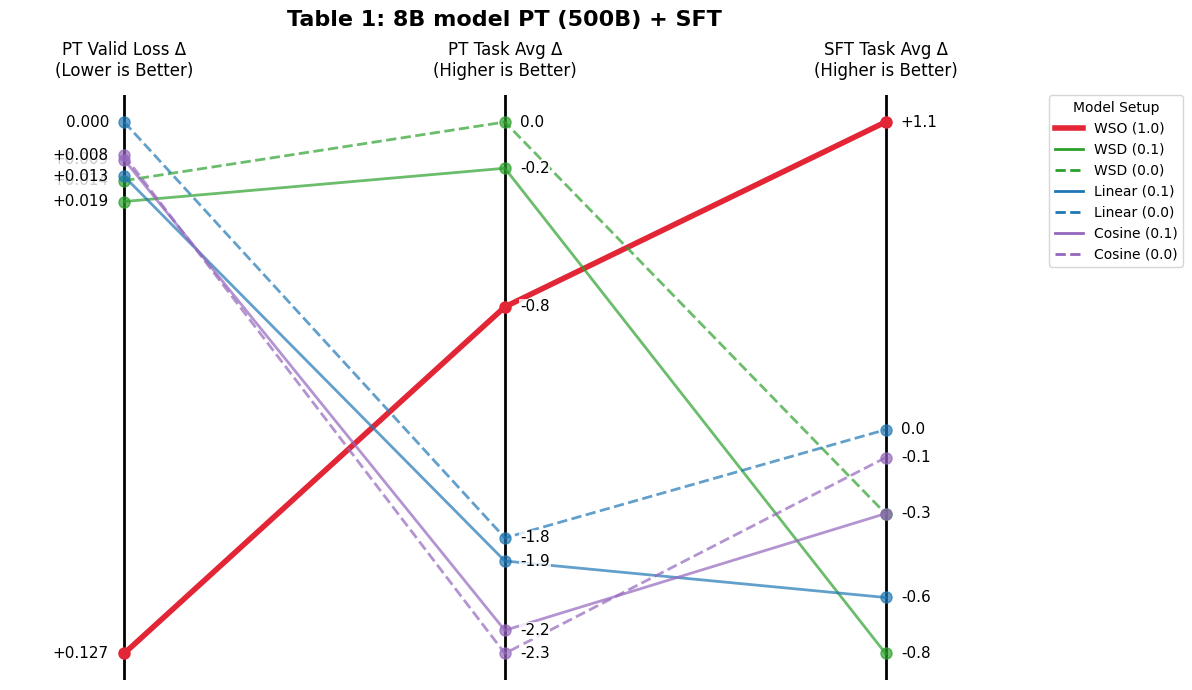

In [93]:
# 1. Raw Data Extraction directly from Table 1 (8B Model)
title = "Table 1: 8B model PT (500B) + SFT"
data_t1_8b = [
    {"Scheduler": "Warmup-Stable-Only (WSO)", "Alpha_pre": "1.0", "PT_Valid_Loss_Delta": 0.127, "PT_Task_Avg_Delta": -0.8, "SFT_Task_Avg_Delta": 1.1, "Label": "WSO (1.0)"},
    {"Scheduler": "WSD", "Alpha_pre": "0.1", "PT_Valid_Loss_Delta": 0.019, "PT_Task_Avg_Delta": -0.2, "SFT_Task_Avg_Delta": -0.8, "Label": "WSD (0.1)"},
    {"Scheduler": "WSD", "Alpha_pre": "0.0", "PT_Valid_Loss_Delta": 0.014, "PT_Task_Avg_Delta": 0.0, "SFT_Task_Avg_Delta": -0.3, "Label": "WSD (0.0)"},
    {"Scheduler": "Linear", "Alpha_pre": "0.1", "PT_Valid_Loss_Delta": 0.013, "PT_Task_Avg_Delta": -1.9, "SFT_Task_Avg_Delta": -0.6, "Label": "Linear (0.1)"},
    {"Scheduler": "Linear", "Alpha_pre": "0.0", "PT_Valid_Loss_Delta": 0.000, "PT_Task_Avg_Delta": -1.8, "SFT_Task_Avg_Delta": 0.0, "Label": "Linear (0.0)"},
    {"Scheduler": "Cosine", "Alpha_pre": "0.1", "PT_Valid_Loss_Delta": 0.009, "PT_Task_Avg_Delta": -2.2, "SFT_Task_Avg_Delta": -0.3, "Label": "Cosine (0.1)"},
    {"Scheduler": "Cosine", "Alpha_pre": "0.0", "PT_Valid_Loss_Delta": 0.008, "PT_Task_Avg_Delta": -2.3, "SFT_Task_Avg_Delta": -0.1, "Label": "Cosine (0.0)"},
]
df_8b = pd.DataFrame(data_t1_8b)

metrics_to_plot = ["PT_Valid_Loss_Delta", "PT_Task_Avg_Delta", "SFT_Task_Avg_Delta"]
metric_display_names = ["PT Valid Loss Δ", "PT Task Avg Δ", "SFT Task Avg Δ"]
directions = ["lower", "higher", "higher"]

# Using your updated function name
visualize_parallel_coordinates(
    df=df_8b, 
    title=title,
    metrics=metrics_to_plot,
    metric_names=metric_display_names,
    metric_directions=directions,
    label_col="Label" 
)

#### 8B PT + MT + SFT

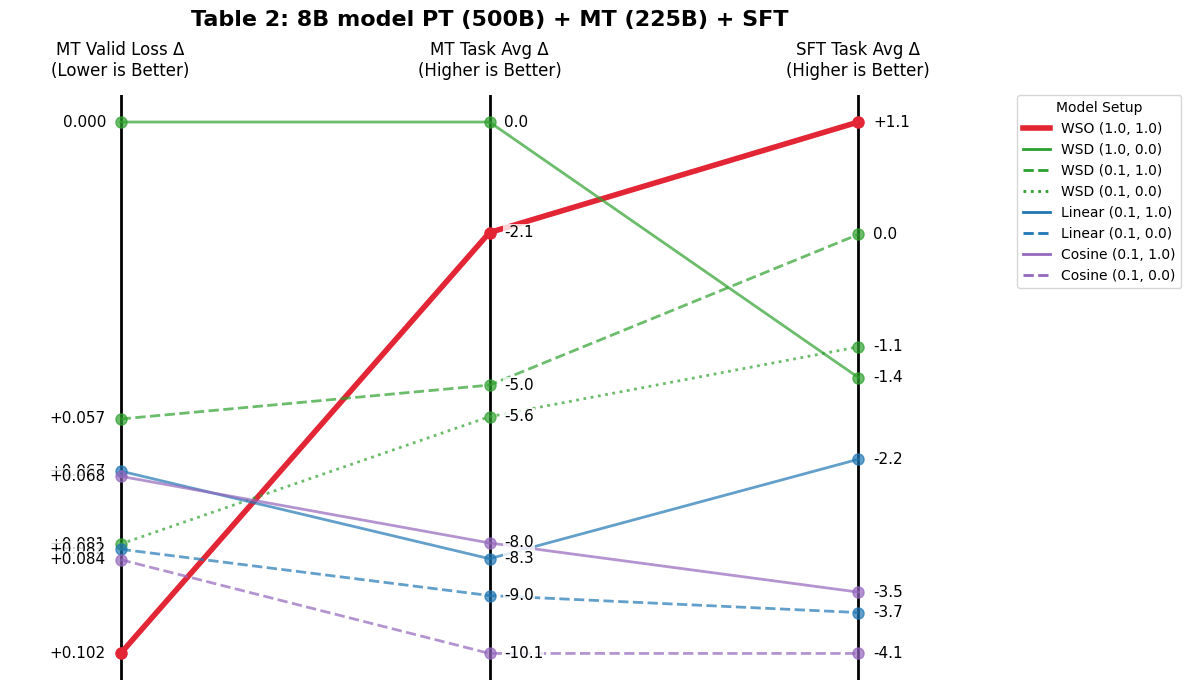

In [94]:
# 1. Raw Data Extraction directly from Table 2 (8B Model)
title = "Table 2: 8B model PT (500B) + MT (225B) + SFT"
data_t2_8b = [
    {"Scheduler": "Warmup-Stable-Only (WSO)", "Alpha_pre": "1.0", "Alpha_mid": "1.0", "MT_Valid_Loss_Delta": 0.102, "MT_Task_Avg_Delta": -2.1, "SFT_Task_Avg_Delta": 1.1, "Label": "WSO (1.0, 1.0)"},
    {"Scheduler": "WSD", "Alpha_pre": "1.0", "Alpha_mid": "0.0", "MT_Valid_Loss_Delta": 0.000, "MT_Task_Avg_Delta": 0.0, "SFT_Task_Avg_Delta": -1.4, "Label": "WSD (1.0, 0.0)"},
    {"Scheduler": "WSD", "Alpha_pre": "0.1", "Alpha_mid": "1.0", "MT_Valid_Loss_Delta": 0.057, "MT_Task_Avg_Delta": -5.0, "SFT_Task_Avg_Delta": 0.0, "Label": "WSD (0.1, 1.0)"},
    {"Scheduler": "WSD", "Alpha_pre": "0.1", "Alpha_mid": "0.0", "MT_Valid_Loss_Delta": 0.081, "MT_Task_Avg_Delta": -5.6, "SFT_Task_Avg_Delta": -1.1, "Label": "WSD (0.1, 0.0)"},
    {"Scheduler": "Linear", "Alpha_pre": "0.1", "Alpha_mid": "1.0", "MT_Valid_Loss_Delta": 0.067, "MT_Task_Avg_Delta": -8.3, "SFT_Task_Avg_Delta": -2.2, "Label": "Linear (0.1, 1.0)"},
    {"Scheduler": "Linear", "Alpha_pre": "0.1", "Alpha_mid": "0.0", "MT_Valid_Loss_Delta": 0.082, "MT_Task_Avg_Delta": -9.0, "SFT_Task_Avg_Delta": -3.7, "Label": "Linear (0.1, 0.0)"},
    {"Scheduler": "Cosine", "Alpha_pre": "0.1", "Alpha_mid": "1.0", "MT_Valid_Loss_Delta": 0.068, "MT_Task_Avg_Delta": -8.0, "SFT_Task_Avg_Delta": -3.5, "Label": "Cosine (0.1, 1.0)"},
    {"Scheduler": "Cosine", "Alpha_pre": "0.1", "Alpha_mid": "0.0", "MT_Valid_Loss_Delta": 0.084, "MT_Task_Avg_Delta": -10.1, "SFT_Task_Avg_Delta": -4.1, "Label": "Cosine (0.1, 0.0)"},
]
df_8b = pd.DataFrame(data_t2_8b)

metrics_to_plot = ["MT_Valid_Loss_Delta", "MT_Task_Avg_Delta", "SFT_Task_Avg_Delta"]
metric_display_names = ["MT Valid Loss Δ", "MT Task Avg Δ", "SFT Task Avg Δ"]
directions = ["lower", "higher", "higher"]

visualize_parallel_coordinates(
    df=df_8b, 
    title=title,
    metrics=metrics_to_plot,
    metric_names=metric_display_names,
    metric_directions=directions,
    label_col="Label" 
)

#### 1B overtraining PT + SFT

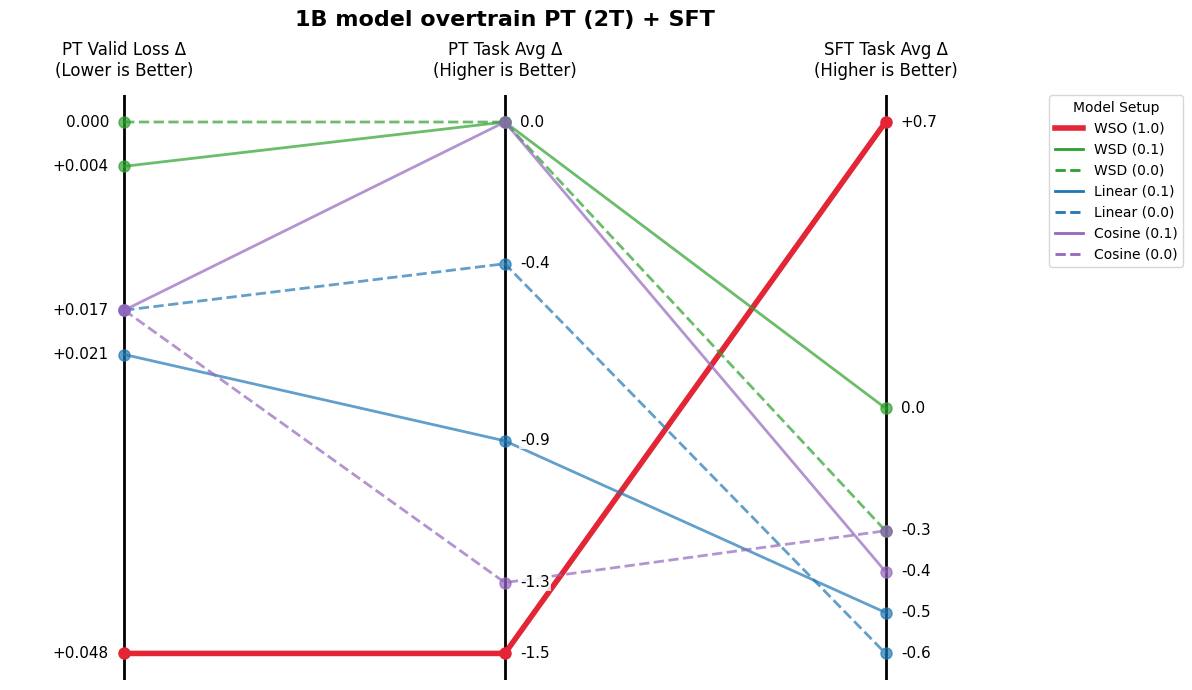

In [95]:
# 1. Raw Data Extraction directly from Table 3
title = "1B model overtrain PT (2T) + SFT"
data_t3 = [
    {"Scheduler": "WSO", "Alpha": "1.0", "PT_Valid_Loss_Delta": 0.048, "PT_Task_Avg_Delta": -1.5, "SFT_Task_Avg_Delta": 0.7, "Label": "WSO (1.0)"},
    {"Scheduler": "WSD", "Alpha": "0.1", "PT_Valid_Loss_Delta": 0.004, "PT_Task_Avg_Delta": 0.0, "SFT_Task_Avg_Delta": 0.0, "Label": "WSD (0.1)"},
    {"Scheduler": "WSD", "Alpha": "0.0", "PT_Valid_Loss_Delta": 0.000, "PT_Task_Avg_Delta": 0.0, "SFT_Task_Avg_Delta": -0.3, "Label": "WSD (0.0)"},
    {"Scheduler": "Linear", "Alpha": "0.1", "PT_Valid_Loss_Delta": 0.021, "PT_Task_Avg_Delta": -0.9, "SFT_Task_Avg_Delta": -0.5, "Label": "Linear (0.1)"},
    {"Scheduler": "Linear", "Alpha": "0.0", "PT_Valid_Loss_Delta": 0.017, "PT_Task_Avg_Delta": -0.4, "SFT_Task_Avg_Delta": -0.6, "Label": "Linear (0.0)"},
    {"Scheduler": "Cosine", "Alpha": "0.1", "PT_Valid_Loss_Delta": 0.017, "PT_Task_Avg_Delta": 0.0, "SFT_Task_Avg_Delta": -0.4, "Label": "Cosine (0.1)"},
    {"Scheduler": "Cosine", "Alpha": "0.0", "PT_Valid_Loss_Delta": 0.017, "PT_Task_Avg_Delta": -1.3, "SFT_Task_Avg_Delta": -0.3, "Label": "Cosine (0.0)"},
]
df = pd.DataFrame(data_t3)

metrics_to_plot = ["PT_Valid_Loss_Delta", "PT_Task_Avg_Delta", "SFT_Task_Avg_Delta"]
metric_display_names = ["PT Valid Loss Δ", "PT Task Avg Δ", "SFT Task Avg Δ"]
directions = ["lower", "higher", "higher"]

visualize_parallel_coordinates(
    df=df, 
    title=title,
    metrics=metrics_to_plot,
    metric_names=metric_display_names,
    metric_directions=directions,
    label_col="Label" # This grabs your pre-formatted scheduler + alphas string
)

#### 1B overtraining PT + MT + SFT

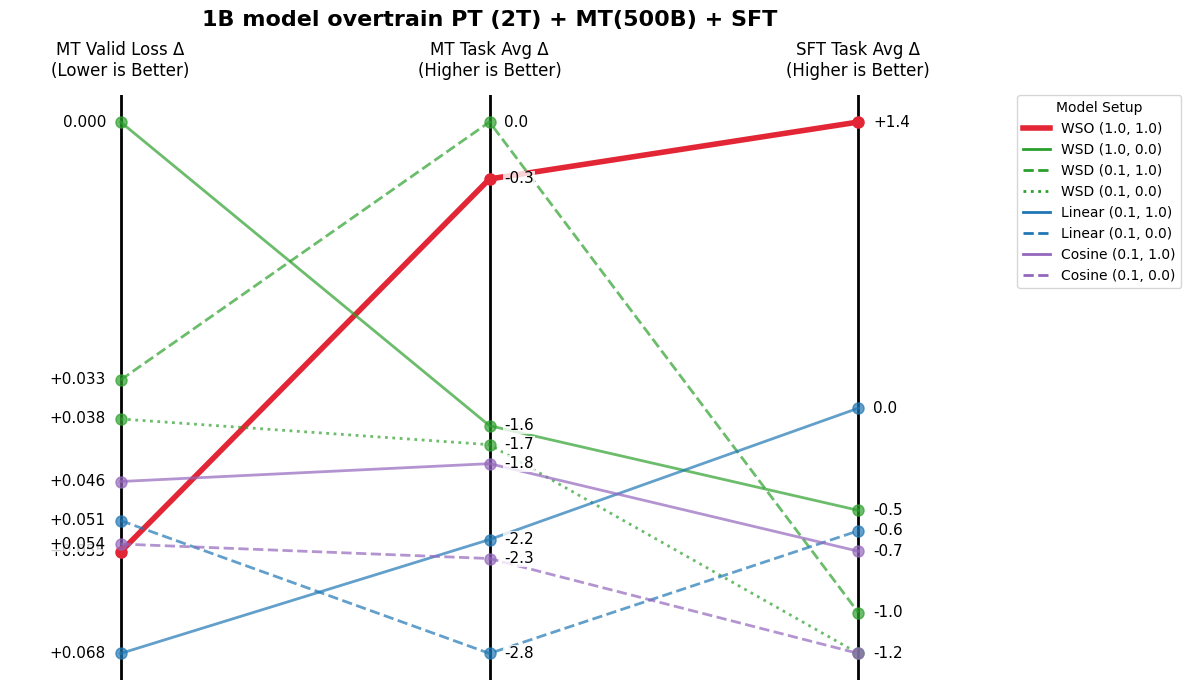

In [96]:
# 1. Raw Data Extraction directly from Table 4
title = "1B model overtrain PT (2T) + MT(500B) + SFT"
data_t4 = [
    {"Scheduler": "Warmup-Stable-Only (WSO)", "Alpha_pre": "1.0", "Alpha_mid": "1.0", "MT_Valid_Loss_Delta": 0.055, "MT_Task_Avg_Delta": -0.3, "SFT_Task_Avg_Delta": 1.4, "Label": "WSO (1.0, 1.0)"},
    {"Scheduler": "WSD", "Alpha_pre": "1.0", "Alpha_mid": "0.0", "MT_Valid_Loss_Delta": 0.000, "MT_Task_Avg_Delta": -1.6, "SFT_Task_Avg_Delta": -0.5, "Label": "WSD (1.0, 0.0)"},
    {"Scheduler": "WSD", "Alpha_pre": "0.1", "Alpha_mid": "1.0", "MT_Valid_Loss_Delta": 0.033, "MT_Task_Avg_Delta": 0.0, "SFT_Task_Avg_Delta": -1.0, "Label": "WSD (0.1, 1.0)"},
    {"Scheduler": "WSD", "Alpha_pre": "0.1", "Alpha_mid": "0.0", "MT_Valid_Loss_Delta": 0.038, "MT_Task_Avg_Delta": -1.7, "SFT_Task_Avg_Delta": -1.2, "Label": "WSD (0.1, 0.0)"},
    {"Scheduler": "Linear", "Alpha_pre": "0.1", "Alpha_mid": "1.0", "MT_Valid_Loss_Delta": 0.068, "MT_Task_Avg_Delta": -2.2, "SFT_Task_Avg_Delta": 0.0, "Label": "Linear (0.1, 1.0)"},
    {"Scheduler": "Linear", "Alpha_pre": "0.1", "Alpha_mid": "0.0", "MT_Valid_Loss_Delta": 0.051, "MT_Task_Avg_Delta": -2.8, "SFT_Task_Avg_Delta": -0.6, "Label": "Linear (0.1, 0.0)"},
    {"Scheduler": "Cosine", "Alpha_pre": "0.1", "Alpha_mid": "1.0", "MT_Valid_Loss_Delta": 0.046, "MT_Task_Avg_Delta": -1.8, "SFT_Task_Avg_Delta": -0.7, "Label": "Cosine (0.1, 1.0)"},
    {"Scheduler": "Cosine", "Alpha_pre": "0.1", "Alpha_mid": "0.0", "MT_Valid_Loss_Delta": 0.054, "MT_Task_Avg_Delta": -2.3, "SFT_Task_Avg_Delta": -1.2, "Label": "Cosine (0.1, 0.0)"},
]
df = pd.DataFrame(data_t4)

# Assuming 'df' is the DataFrame created from 'data_t4'

metrics_to_plot = ["MT_Valid_Loss_Delta", "MT_Task_Avg_Delta", "SFT_Task_Avg_Delta"]
metric_display_names = ["MT Valid Loss Δ", "MT Task Avg Δ", "SFT Task Avg Δ"]
directions = ["lower", "higher", "higher"]

visualize_parallel_coordinates(
    df=df, 
    title=title,
    metrics=metrics_to_plot,
    metric_names=metric_display_names,
    metric_directions=directions,
    label_col="Label" # This grabs your pre-formatted scheduler + alphas string
)

#### 1B overtraining PT + MT + SFT

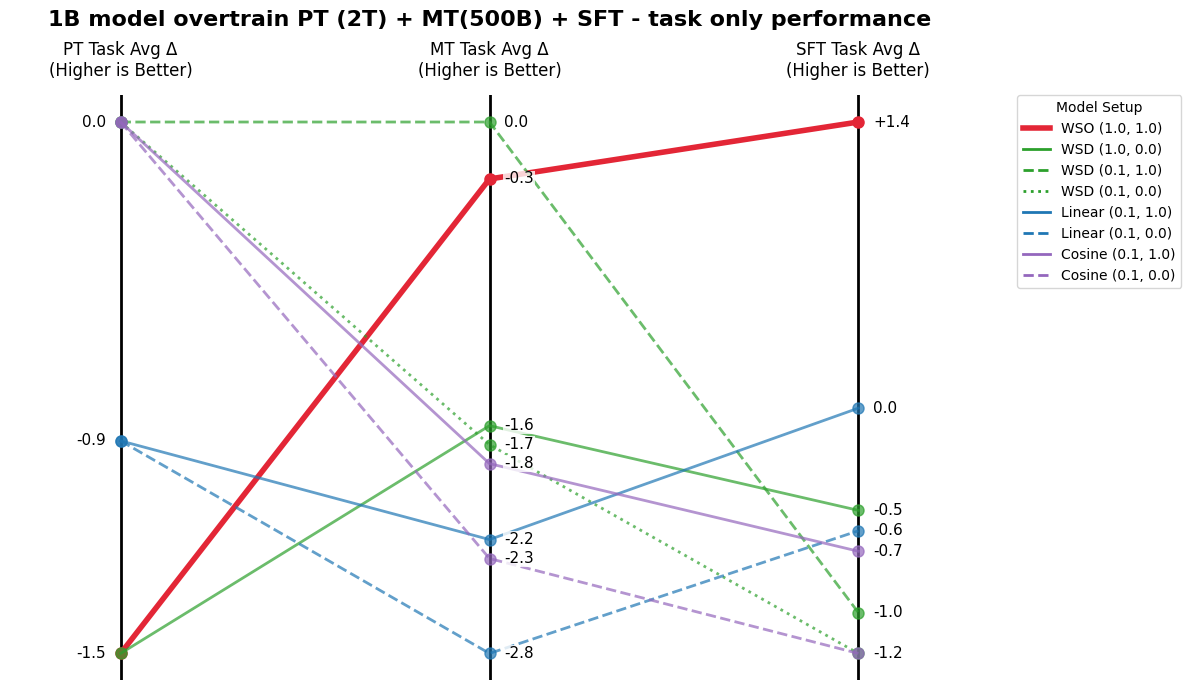

In [97]:
# 1. Raw Data Extraction directly from Table 4
title = "1B model overtrain PT (2T) + MT(500B) + SFT - task only performance"
data_t4 = [
    {"Scheduler": "Warmup-Stable-Only (WSO)", "Alpha_pre": "1.0", "Alpha_mid": "1.0", "PT_Task_Avg_Delta": -1.5, "MT_Task_Avg_Delta": -0.3, "SFT_Task_Avg_Delta": 1.4, "Label": "WSO (1.0, 1.0)"},
    {"Scheduler": "WSD", "Alpha_pre": "1.0", "Alpha_mid": "0.0", "PT_Task_Avg_Delta": -1.5, "MT_Task_Avg_Delta": -1.6, "SFT_Task_Avg_Delta": -0.5, "Label": "WSD (1.0, 0.0)"},
    {"Scheduler": "WSD", "Alpha_pre": "0.1", "Alpha_mid": "1.0", "PT_Task_Avg_Delta": 0.0, "MT_Task_Avg_Delta": 0.0, "SFT_Task_Avg_Delta": -1.0, "Label": "WSD (0.1, 1.0)"},
    {"Scheduler": "WSD", "Alpha_pre": "0.1", "Alpha_mid": "0.0", "PT_Task_Avg_Delta": 0.0, "MT_Task_Avg_Delta": -1.7, "SFT_Task_Avg_Delta": -1.2, "Label": "WSD (0.1, 0.0)"},
    {"Scheduler": "Linear", "Alpha_pre": "0.1", "Alpha_mid": "1.0", "PT_Task_Avg_Delta": -0.9, "MT_Task_Avg_Delta": -2.2, "SFT_Task_Avg_Delta": 0.0, "Label": "Linear (0.1, 1.0)"},
    {"Scheduler": "Linear", "Alpha_pre": "0.1", "Alpha_mid": "0.0", "PT_Task_Avg_Delta": -0.9, "MT_Task_Avg_Delta": -2.8, "SFT_Task_Avg_Delta": -0.6, "Label": "Linear (0.1, 0.0)"},
    {"Scheduler": "Cosine", "Alpha_pre": "0.1", "Alpha_mid": "1.0", "PT_Task_Avg_Delta": 0.0, "MT_Task_Avg_Delta": -1.8, "SFT_Task_Avg_Delta": -0.7, "Label": "Cosine (0.1, 1.0)"},
    {"Scheduler": "Cosine", "Alpha_pre": "0.1", "Alpha_mid": "0.0", "PT_Task_Avg_Delta": 0.0, "MT_Task_Avg_Delta": -2.3, "SFT_Task_Avg_Delta": -1.2, "Label": "Cosine (0.1, 0.0)"},
]
df = pd.DataFrame(data_t4)

# Assuming 'df' is the DataFrame created from 'data_t4'

metrics_to_plot = ["PT_Task_Avg_Delta", "MT_Task_Avg_Delta", "SFT_Task_Avg_Delta"]
metric_display_names = ["PT Task Avg Δ", "MT Task Avg Δ", "SFT Task Avg Δ"]
directions = ["higher", "higher", "higher"]

visualize_parallel_coordinates(
    df=df, 
    title=title,
    metrics=metrics_to_plot,
    metric_names=metric_display_names,
    metric_directions=directions,
    label_col="Label" # This grabs your pre-formatted scheduler + alphas string
)

#### 1B PT + MT + SFT - task only (report 3 stages)

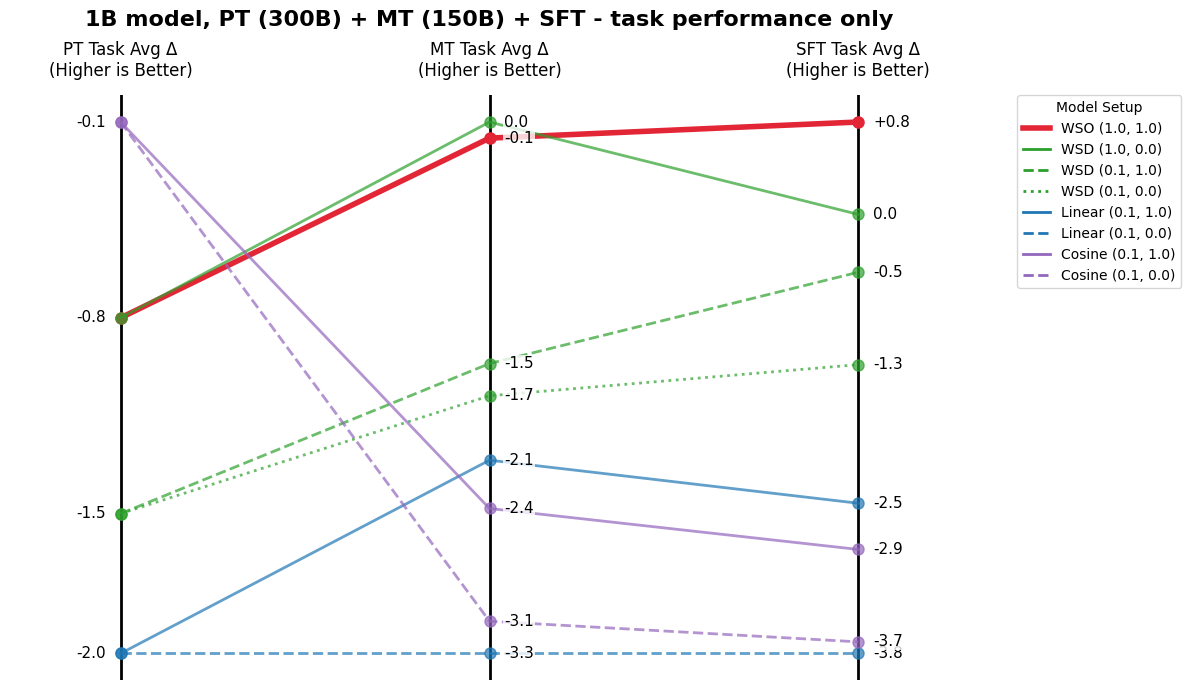

In [98]:
# 1. Raw Data Extraction directly from Table 1 (1B Model)
title = "1B model, PT (300B) + MT (150B) + SFT - task performance only"

data_t1_1b = [
    {"Scheduler": "Warmup-Stable-Only (WSO)", "Alpha_pre": "1.0", "Alpha_mid": "1.0", "PT_Task_Avg_Delta": -0.8, "MT_Task_Avg_Delta": -0.1, "SFT_Task_Avg_Delta": 0.8, "Label": "WSO (1.0, 1.0)"},
    {"Scheduler": "WSD", "Alpha_pre": "1.0", "Alpha_mid": "0.0", "PT_Task_Avg_Delta": -0.8, "MT_Task_Avg_Delta": 0.0, "SFT_Task_Avg_Delta": 0.0, "Label": "WSD (1.0, 0.0)"},
    {"Scheduler": "WSD", "Alpha_pre": "0.1", "Alpha_mid": "1.0", "PT_Task_Avg_Delta": -1.5, "MT_Task_Avg_Delta": -1.5, "SFT_Task_Avg_Delta": -0.5, "Label": "WSD (0.1, 1.0)"},
    {"Scheduler": "WSD", "Alpha_pre": "0.1", "Alpha_mid": "0.0", "PT_Task_Avg_Delta": -1.5, "MT_Task_Avg_Delta": -1.7, "SFT_Task_Avg_Delta": -1.3, "Label": "WSD (0.1, 0.0)"},
    {"Scheduler": "Linear", "Alpha_pre": "0.1", "Alpha_mid": "1.0", "PT_Task_Avg_Delta": -2.0, "MT_Task_Avg_Delta": -2.1, "SFT_Task_Avg_Delta": -2.5, "Label": "Linear (0.1, 1.0)"},
    {"Scheduler": "Linear", "Alpha_pre": "0.1", "Alpha_mid": "0.0", "PT_Task_Avg_Delta": -2.0, "MT_Task_Avg_Delta": -3.3, "SFT_Task_Avg_Delta": -3.8, "Label": "Linear (0.1, 0.0)"},
    {"Scheduler": "Cosine", "Alpha_pre": "0.1", "Alpha_mid": "1.0", "PT_Task_Avg_Delta": -0.1, "MT_Task_Avg_Delta": -2.4, "SFT_Task_Avg_Delta": -2.9, "Label": "Cosine (0.1, 1.0)"},
    {"Scheduler": "Cosine", "Alpha_pre": "0.1", "Alpha_mid": "0.0", "PT_Task_Avg_Delta": -0.1, "MT_Task_Avg_Delta": -3.1, "SFT_Task_Avg_Delta": -3.7, "Label": "Cosine (0.1, 0.0)"},
]

df_1b = pd.DataFrame(data_t1_1b)

metrics_to_plot = ["PT_Task_Avg_Delta", "MT_Task_Avg_Delta", "SFT_Task_Avg_Delta"]
metric_display_names = ["PT Task Avg Δ", "MT Task Avg Δ", "SFT Task Avg Δ"]
directions = ["higher", "higher", "higher"]

# Using your updated function name
visualize_parallel_coordinates(
    df=df_1b, 
    title=title,
    metrics=metrics_to_plot,
    metric_names=metric_display_names,
    metric_directions=directions,
    label_col="Label" 
)

#### 8B PT + MT + SFT - task only (report 3 stages)

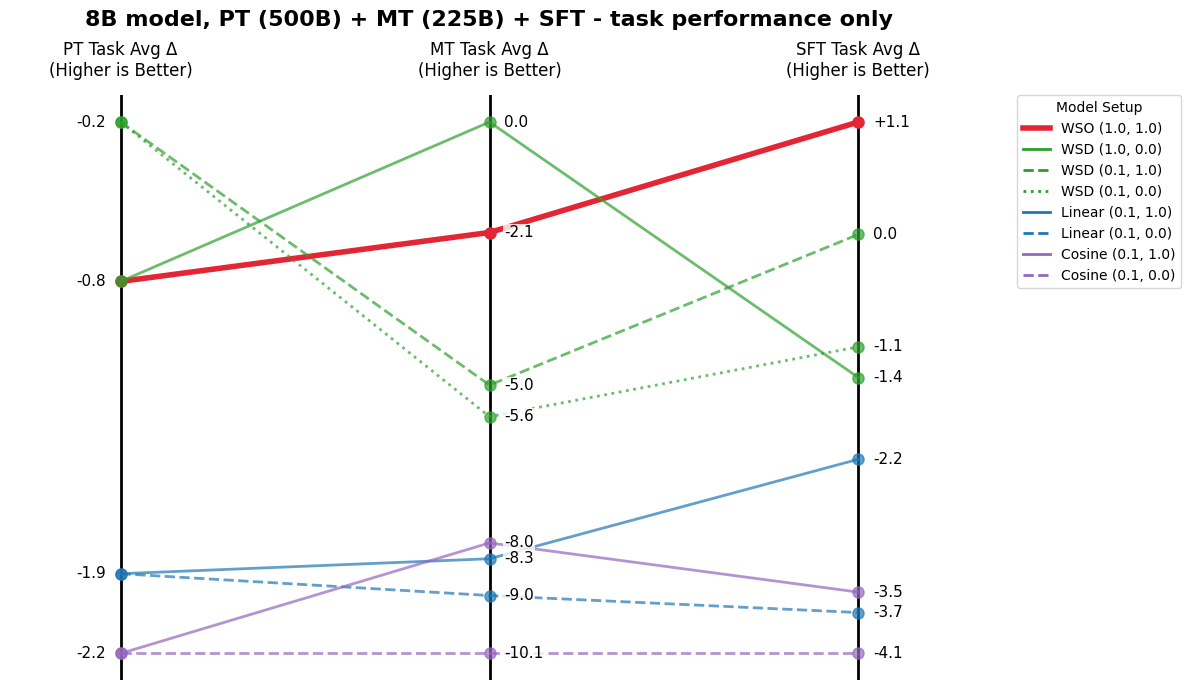

In [99]:
# 1. Raw Data Extraction directly from Table 1 (1B Model)
title = "8B model, PT (500B) + MT (225B) + SFT - task performance only"

data_t1_1b = [
    {"Scheduler": "Warmup-Stable-Only (WSO)", "Alpha_pre": "1.0", "Alpha_mid": "1.0", "PT_Task_Avg_Delta": -0.8, "MT_Task_Avg_Delta": -2.1, "SFT_Task_Avg_Delta": 1.1, "Label": "WSO (1.0, 1.0)"},
    {"Scheduler": "WSD", "Alpha_pre": "1.0", "Alpha_mid": "0.0", "PT_Task_Avg_Delta": -0.8, "MT_Task_Avg_Delta": 0.0, "SFT_Task_Avg_Delta": -1.4, "Label": "WSD (1.0, 0.0)"},
    {"Scheduler": "WSD", "Alpha_pre": "0.1", "Alpha_mid": "1.0", "PT_Task_Avg_Delta": -0.2, "MT_Task_Avg_Delta": -5.0, "SFT_Task_Avg_Delta": 0.0, "Label": "WSD (0.1, 1.0)"},
    {"Scheduler": "WSD", "Alpha_pre": "0.1", "Alpha_mid": "0.0", "PT_Task_Avg_Delta": -0.2, "MT_Task_Avg_Delta": -5.6, "SFT_Task_Avg_Delta": -1.1, "Label": "WSD (0.1, 0.0)"},
    {"Scheduler": "Linear", "Alpha_pre": "0.1", "Alpha_mid": "1.0", "PT_Task_Avg_Delta": -1.9, "MT_Task_Avg_Delta": -8.3, "SFT_Task_Avg_Delta": -2.2, "Label": "Linear (0.1, 1.0)"},
    {"Scheduler": "Linear", "Alpha_pre": "0.1", "Alpha_mid": "0.0", "PT_Task_Avg_Delta": -1.9, "MT_Task_Avg_Delta": -9.0, "SFT_Task_Avg_Delta": -3.7, "Label": "Linear (0.1, 0.0)"},
    {"Scheduler": "Cosine", "Alpha_pre": "0.1", "Alpha_mid": "1.0", "PT_Task_Avg_Delta": -2.2, "MT_Task_Avg_Delta": -8.0, "SFT_Task_Avg_Delta": -3.5, "Label": "Cosine (0.1, 1.0)"},
    {"Scheduler": "Cosine", "Alpha_pre": "0.1", "Alpha_mid": "0.0", "PT_Task_Avg_Delta": -2.2, "MT_Task_Avg_Delta": -10.1, "SFT_Task_Avg_Delta": -4.1, "Label": "Cosine (0.1, 0.0)"},
]

df_1b = pd.DataFrame(data_t1_1b)

metrics_to_plot = ["PT_Task_Avg_Delta", "MT_Task_Avg_Delta", "SFT_Task_Avg_Delta"]
metric_display_names = ["PT Task Avg Δ", "MT Task Avg Δ", "SFT Task Avg Δ"]
directions = ["higher", "higher", "higher"]

# Using your updated function name
visualize_parallel_coordinates(
    df=df_1b, 
    title=title,
    metrics=metrics_to_plot,
    metric_names=metric_display_names,
    metric_directions=directions,
    label_col="Label" 
)